## 📦 Importieren der wichtigsten Bibliotheken für Datenanalyse & Visualisierung

Zu Beginn der Datenanalyse laden wir die zentralen Python‑Bibliotheken:


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 📥 Laden des Datensatzes

Im nächsten Schritt laden wir die Transaktionsdaten aus der CSV‑Datei.  
Der Datensatz befindet sich im Projektordner unter *data/raw/*.



In [3]:
df = pd.read_csv(r"C:\Users\shiva\OneDrive\Desktop\weiter bildung\projekt\fraud-detection-realtime-main\data\raw\transactions.csv")
df.head()


,transaction_id,amount,country,device,timestamp,time_since_last,is_fraud
0,1,150.31,FR,POS,2024-01-01 00:00:28.156085,0.000000,0
1,2,54.58,CN,POS,2024-01-01 00:03:28.763371,180.607286,0
2,3,17.40,PL,Mobile,2024-01-01 00:04:47.768113,79.004742,0
3,4,106.74,US,POS,2024-01-01 00:05:42.544666,54.776553,0
4,5,43.40,DE,Mobile,2024-01-01 00:05:52.722158,10.177492,0


## 🧾 Überblick über den Datensatz

Nachdem der Datensatz geladen wurde, verschaffen wir uns nun einen ersten strukturellen Überblick.  
Dazu betrachten wir die **Spalten**, **Datentypen**, **Grundstatistiken** und prüfen auf **fehlende Werte**.


In [4]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   50000 non-null  int64  
 1   amount           50000 non-null  float64
 2   country          50000 non-null  object 
 3   device           50000 non-null  object 
 4   timestamp        50000 non-null  object 
 5   time_since_last  50000 non-null  float64
 6   is_fraud         50000 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 2.7+ MB


transaction_id     0
amount             0
country            0
device             0
timestamp          0
time_since_last    0
is_fraud           0
dtype: int64

## 📊 Visualisierung der Merkmalsverteilungen (Histogramme)

Um ein erstes Gefühl für die Verteilung der numerischen Variablen zu bekommen,  
erstellen wir Histogramme für alle numerischen Spalten im Datensatz.


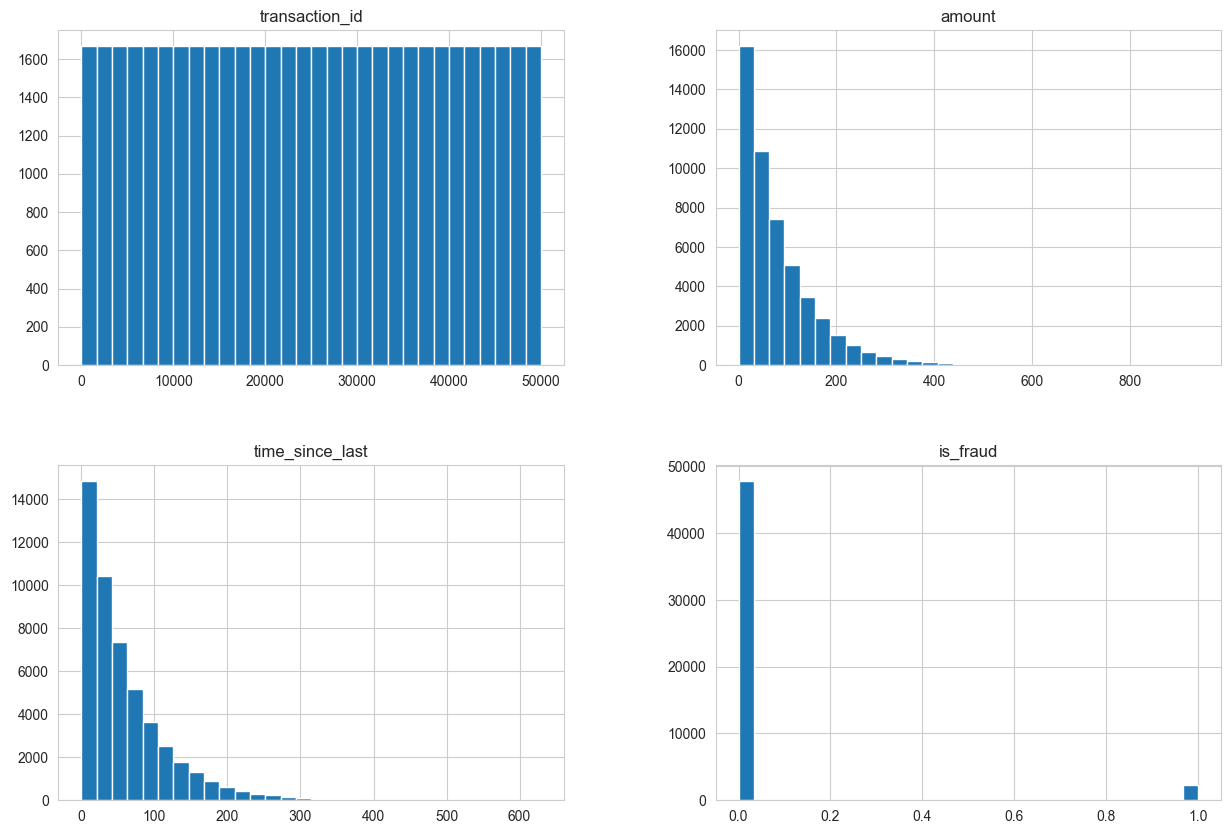

In [5]:
df.hist(figsize=(15, 10), bins=30)
plt.show()

## ⚖️ Verteilung der Zielvariable: Fraud vs. Non‑Fraud

Um zu verstehen, wie unausgeglichen (imbalanced) der Datensatz ist,  
visualisieren wir die Häufigkeit der beiden Klassen **Fraud (1)** und **Non‑Fraud (0)**.

Text(0.5, 1.0, 'Fraud vs Non-Fraud Distribution')

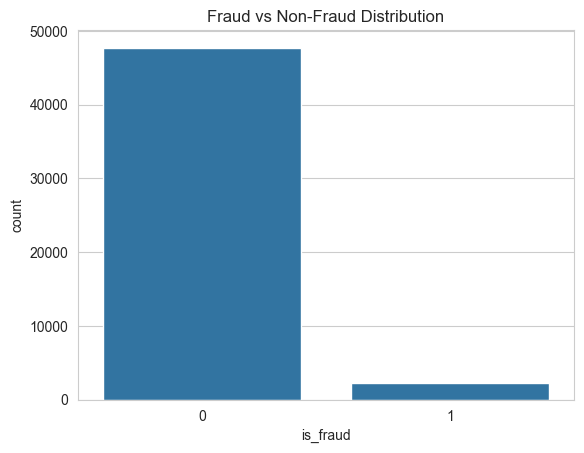

In [6]:
sns.countplot(data=df, x="is_fraud")
plt.title("Fraud vs Non-Fraud Distribution")

## 🔥 Korrelationsanalyse der numerischen Variablen (Heatmap)

Um Zusammenhänge zwischen den numerischen Merkmalen besser zu verstehen,  
erstellen wir eine Korrelationsmatrix und visualisieren sie als Heatmap.


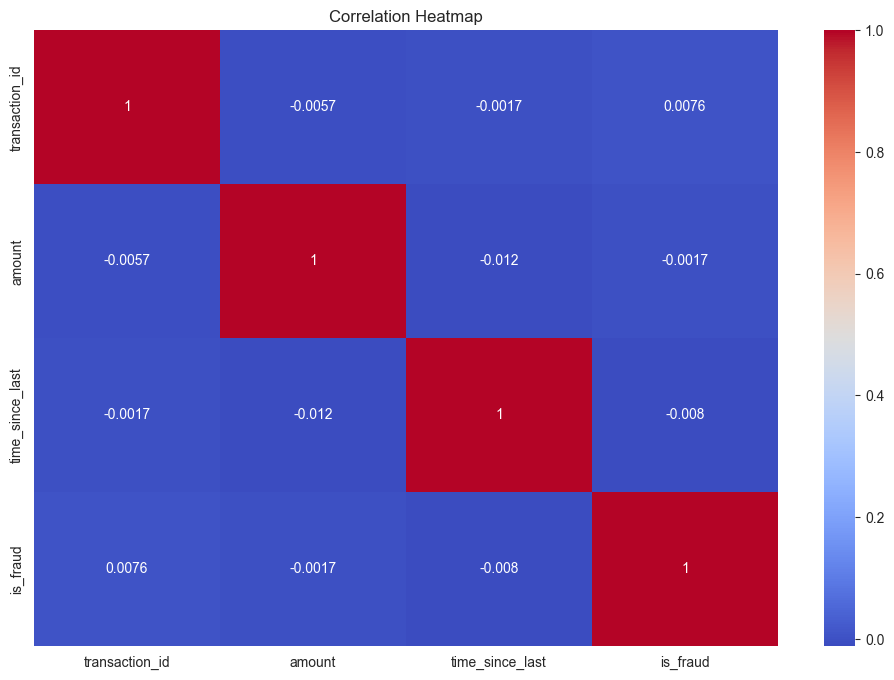

In [7]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()


## 📦 Analyse der Betragsverteilung nach Fraud‑Status (Boxplot)

Um zu untersuchen, wie sich der Transaktionsbetrag (**amount**) zwischen  
legitimen und betrügerischen Transaktionen unterscheidet, erstellen wir einen Boxplot.


Text(0.5, 1.0, 'Amount Distribution by Fraud Status')

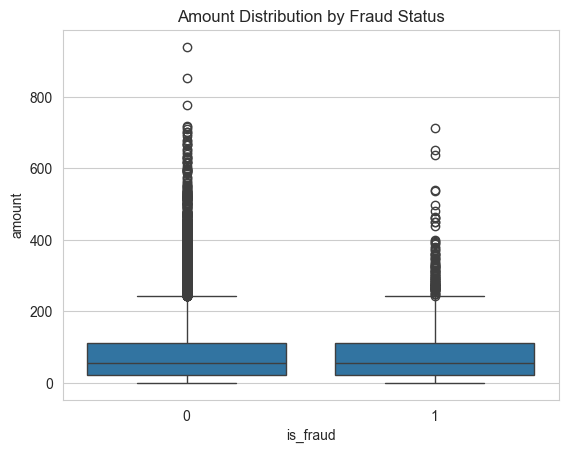

In [8]:
sns.boxplot(data=df, x="is_fraud", y="amount")
plt.title("Amount Distribution by Fraud Status")
